In [57]:
import pandas as pd

In [58]:
df = pd.read_csv(r"C:\Users\DELL\Desktop\Classes\Machine Learning\Datasets\Data_Missing_outliers.csv")

In [59]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Unnamed: 0          5000 non-null   int64  
 1   age                 4500 non-null   float64
 2   experience_years    5000 non-null   int64  
 3   salary              4500 non-null   float64
 4   projects_completed  5000 non-null   int64  
 5   department          5000 non-null   object 
 6   education           4500 non-null   object 
 7   city                5000 non-null   object 
 8   remote_work         5000 non-null   object 
dtypes: float64(2), int64(3), object(4)
memory usage: 351.7+ KB


When working with **numerical features, scaling ensures that all features are on a similar range**, which helps many ML algorithms (especially **distance-based algorithms** like KNN, SVM).

## 1. Standard Scaling (Z-Score Normalization)

Standard scaling transforms data so that:

    - Mean = 0
    - Standard deviation = 1

`Formula`

(x - mean) / standard_deviation

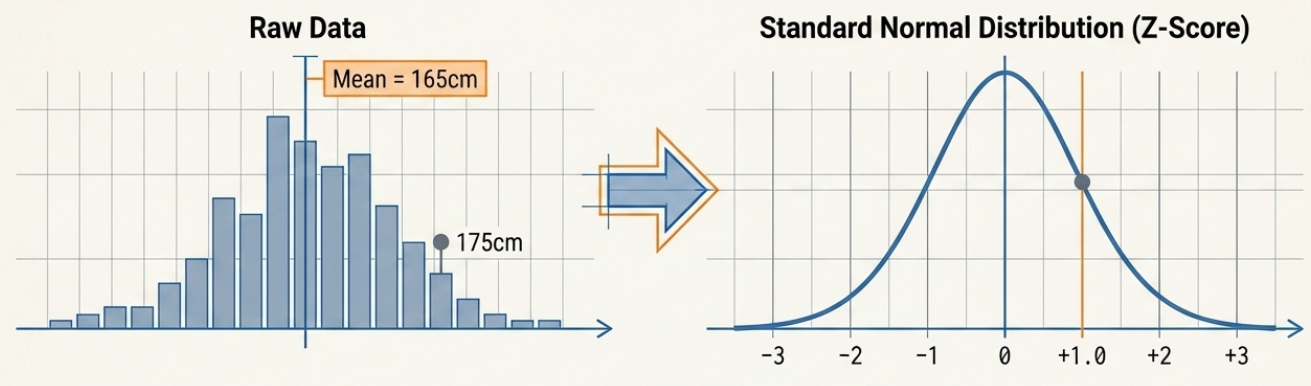

##### When to Use

- Data is **normally distributed**
- Algorithms rely on distance

- Sensitive to **outliers**

In [5]:
df["age"].fillna(34,inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23244\3786668922.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["age"].fillna(34,inplace=True)


In [6]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

df["age_scaled"] = scaler.fit_transform(df[["age"]])

In [7]:
df["age_scaled"].min(), df["age_scaled"].max()

(-3.735544773623017, 4.240676725421999)

In [8]:
df["salary"].fillna(df["salary"].mean(),inplace=True)

C:\Users\DELL\AppData\Local\Temp\ipykernel_23244\3472753723.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["salary"].fillna(df["salary"].mean(),inplace=True)


In [9]:
df["salary_scaled"] = scaler.fit_transform(df[["salary"]])

In [10]:
df["salary_scaled"].min(), df["salary_scaled"].max()

(-1.806069976309548, 13.99166740347275)

### 2. Min-Max Scaling (Normalization)

- Rescales values into a fixed range.

- Usually between `0 and 1`.

`Formula`

(x - min) / (max - min)

**Problems**

- Highly sensitive to outliers.

- One extreme value can distort the scale.

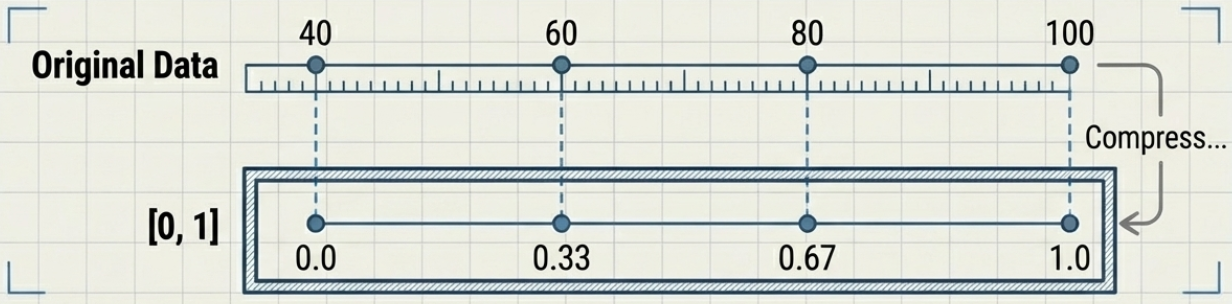

In [11]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

df["salary_scaled"] = scaler.fit_transform(df[["salary"]])

In [12]:
df["salary_scaled"].min(), df["salary_scaled"].max()

(0.0, 1.0)

### 3. Max Absolute Scaling

- Scales data by dividing by the **maximum absolute value**.

`Formula`

x / max(|x|)

- Range becomes **-1 to 1**.

**When to Use**
- Sparse datasets
- Text vectorization data

`Example`:
TF-IDF matrices.

In [13]:
from sklearn.preprocessing import MaxAbsScaler

scaler = MaxAbsScaler()

df["salary_scaled"] = scaler.fit_transform(df[["salary"]])

In [14]:
df["salary_scaled"].min(), df["salary_scaled"].max()

(0.02162537548153978, 1.0)

### 4. Robust Scaling

- **Uses median and IQR (Interquartile Range) instead of mean**.

`Formula`

(x - median) / IQR

**When to Use**

- Data contains many outliers
- Distribution is skewed

- Advantage is Very robust against outliers.

In [15]:
from sklearn.preprocessing import RobustScaler

scaler = RobustScaler()

df["salary_scaled"] = scaler.fit_transform(df[["salary"]])

In [16]:
df["salary_scaled"].min(), df["salary_scaled"].max()

(-2.9510744968213287, 23.030537771473785)

| Technique      | Range               | Best For            | Outlier Handling |
| -------------- | ------------------- | ------------------- | ---------------- |
| StandardScaler | centered            | normal distribution | poor             |
| MinMaxScaler   | 0–1                 | neural networks     | poor             |
| MaxAbsScaler   | -1 to 1             | sparse data         | poor             |
| RobustScaler   | centered            | outliers            | good             |
| Log Transform  | compressed          | skewed data         | moderate         |
| Sqrt Transform | mild compression    | moderate skew       | moderate         |
| PowerTransform | normal distribution | heavy skew          | good             |


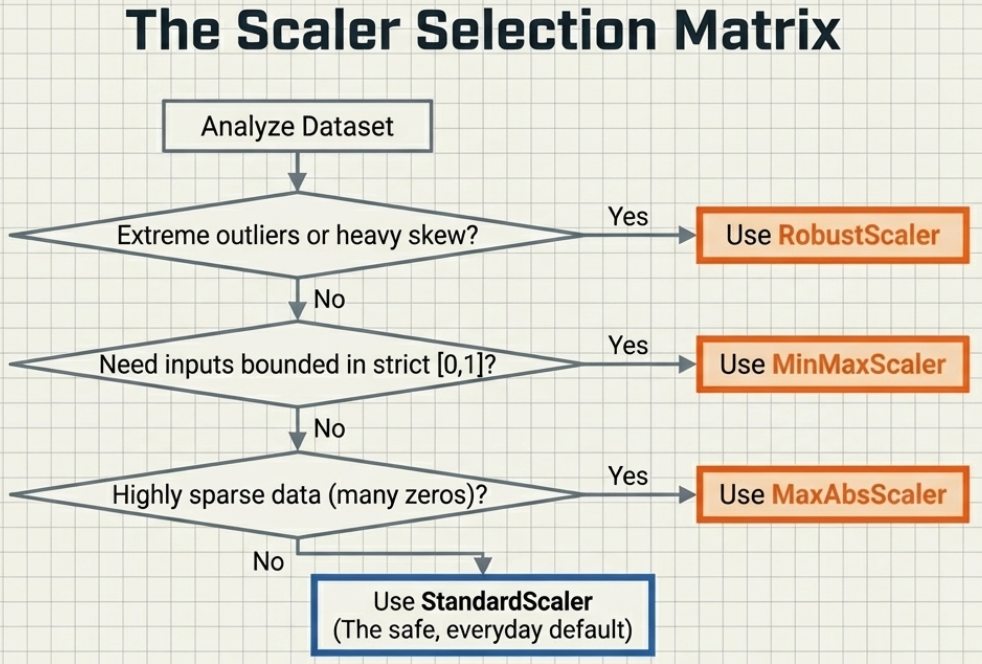

In [4]:
from sklearn.compose import ColumnTransformer

In [19]:
from sklearn.preprocessing import OneHotEncoder

In [21]:
df.columns

Index(['Unnamed: 0', 'age', 'experience_years', 'salary', 'projects_completed',
       'department', 'education', 'city', 'remote_work', 'age_scaled',
       'salary_scaled'],
      dtype='object')

In [28]:
transformer = ColumnTransformer(transformers=[
    ("OneHot",OneHotEncoder(),["city"]),
    ("Standard",StandardScaler(),["age"]),
    ("MinMax",MinMaxScaler(),["salary"])
],remainder="passthrough")

In [30]:
trans_data = transformer.fit_transform(df)

In [31]:
trans_data[0]

array([0.0, 1.0, 0.0, 0.0, -0.17858113215699672, 0.1016787376571228, 0, 6,
       6, 'IT', 'PhD', 'Yes', -0.17858113215699672, -0.3092969590842661],
      dtype=object)

### Why Scaling is Important (Distance Problem)
Concept

- Distance-based algorithms like K-Nearest Neighbors are heavily affected by feature scale.

In [66]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances

df = pd.DataFrame({
    "Age":[25,30],
    "Salary":[20000,80000]
})

print("Original Data")
print(df)

print("\nDistance Without Scaling")
print(euclidean_distances(df))

scaler = StandardScaler()
scaled = scaler.fit_transform(df)

rob_scalar = RobustScaler()
robust = rob_scalar.fit_transform(df)

print("\nDistance After Scaling")
print(euclidean_distances(scaled))
print("\nDistance After Scaling Robust")
print(euclidean_distances(robust))

Original Data
   Age  Salary
0   25   20000
1   30   80000

Distance Without Scaling
[[    0.         60000.00020833]
 [60000.00020833     0.        ]]

Distance After Scaling
[[0.         2.82842712]
 [2.82842712 0.        ]]

Distance After Scaling Robust
[[0.         2.82842712]
 [2.82842712 0.        ]]


#### how outliers destroy MinMaxScaler

In [68]:
import numpy as np
salary = np.array([30000,35000,40000,42000,45000,47000,50000]).reshape(-1,1)

df = pd.DataFrame(salary, columns=["Salary"])

In [69]:
from sklearn.preprocessing import MinMaxScaler, RobustScaler
scaler = MinMaxScaler()
rob_scaler = RobustScaler()

df["Scaled_Normal"] = scaler.fit_transform(df[["Salary"]])
df["Robust_normal"] = rob_scaler.fit_transform(df[["Salary"]])


print(df)

   Salary  Scaled_Normal  Robust_normal
0   30000           0.00      -1.411765
1   35000           0.25      -0.823529
2   40000           0.50      -0.235294
3   42000           0.60       0.000000
4   45000           0.75       0.352941
5   47000           0.85       0.588235
6   50000           1.00       0.941176


In [70]:
salary_outlier = np.append(salary, 1000000).reshape(-1,1)

df_outlier = pd.DataFrame(salary_outlier, columns=["Salary"])

In [72]:
scaler = MinMaxScaler()

df_outlier["Scaled_With_Outlier"] = scaler.fit_transform(df_outlier[["Salary"]])
df_outlier["Scaled_With_Outlier_Robust"] = rob_scalar.fit_transform(df_outlier[["Salary"]])

print(df_outlier)

    Salary  Scaled_With_Outlier  Scaled_With_Outlier_Robust
0    30000             0.000000                   -1.500000
1    35000             0.005155                   -0.944444
2    40000             0.010309                   -0.388889
3    42000             0.012371                   -0.166667
4    45000             0.015464                    0.166667
5    47000             0.017526                    0.388889
6    50000             0.020619                    0.722222
7  1000000             1.000000                  106.277778


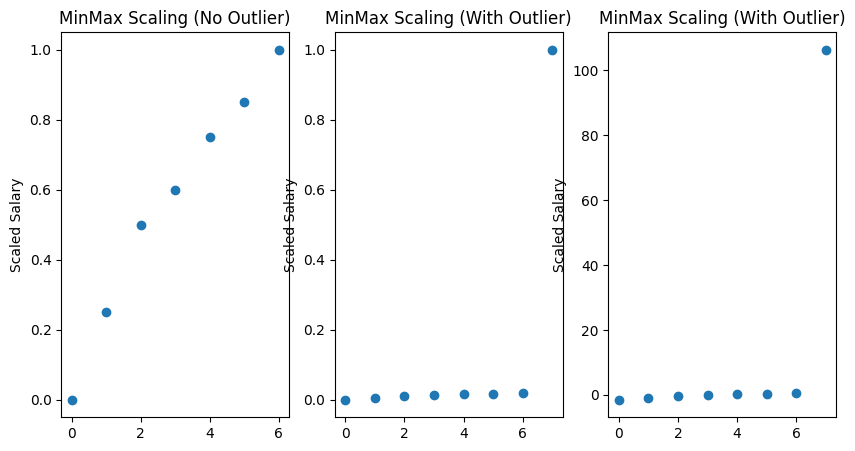

In [73]:
plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.scatter(df.index, df["Scaled_Normal"])
plt.title("MinMax Scaling (No Outlier)")
plt.ylabel("Scaled Salary")

plt.subplot(1,3,2)
plt.scatter(df_outlier.index, df_outlier["Scaled_With_Outlier"])
plt.title("MinMax Scaling (With Outlier)")
plt.ylabel("Scaled Salary")

plt.subplot(1,3,3)
plt.scatter(df_outlier.index, df_outlier["Scaled_With_Outlier_Robust"])
plt.title("MinMax Scaling (With Outlier)")
plt.ylabel("Scaled Salary")


plt.show()